# 02. Data Preprocessing & Feature Engineering

**Objectives:**
- Clean and preprocess raw data
- Handle missing values and outliers
- Resample to hourly frequency
- Create time-based features
- Create features for association mining, clustering, and forecasting

In [ ]:
# Import libraries
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import PowerDataLoader
from src.data.cleaner import PowerDataCleaner
from src.features.builder import PowerFeatureBuilder
from src.visualization.plots import PowerVisualizer

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Raw Data

In [4]:
# Load raw data
config_path = '../configs/params.yaml'
data_path = '../data/raw/household_power_consumption.txt'
loader = PowerDataLoader(config_path=config_path)
df_raw = loader.load_raw_data(file_path=data_path)

print(f"Raw data shape: {df_raw.shape}")
print(f"Missing values: {df_raw.isnull().sum().sum()}")

Loading data from ../data/raw/household_power_consumption.txt...
Loaded 2075259 rows, 7 columns
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Raw data shape: (2075259, 7)
Missing values: 181853


## 2. Data Cleaning Pipeline

In [6]:
# Initialize cleaner
cleaner = PowerDataCleaner(config_path='../configs/params.yaml')

# Run full cleaning pipeline
df_clean = cleaner.clean_pipeline(df_raw)

print(f"\nCleaned data shape: {df_clean.shape}")
print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")

Starting data cleaning pipeline...

1. Handling missing values...
Missing values after handling: 0

2. Resampling data...
Resampling from 2075259 rows to 1H frequency...
Resampled to 34589 rows

3. Detecting outliers...
Detected 6665 outlier rows (19.27%)

Data cleaning completed!

Cleaned data shape: (34589, 8)
Missing values after cleaning: 0



Outliers detected: 6665 (19.27%)


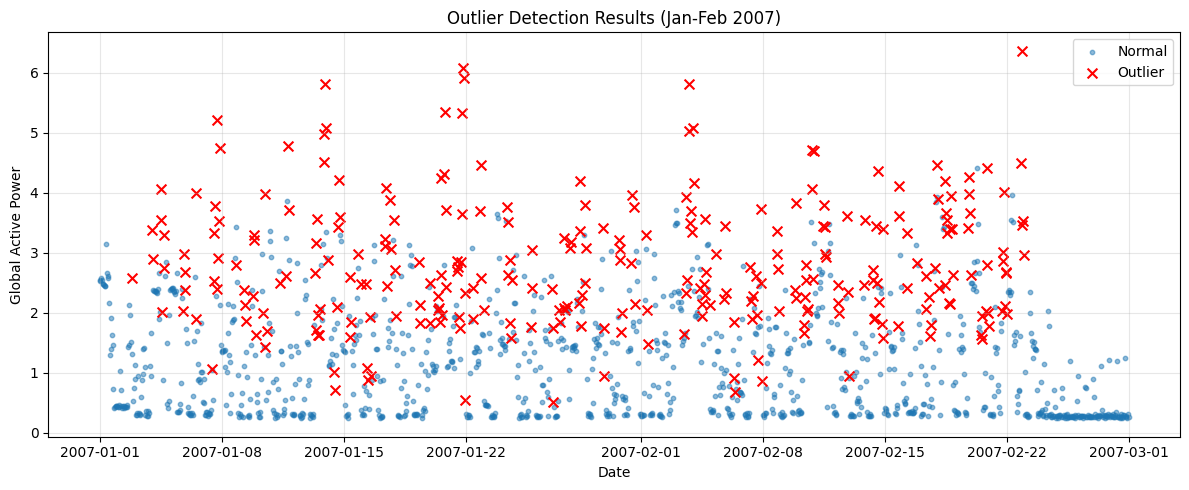

In [7]:
# Check outliers
if 'is_outlier' in df_clean.columns:
    n_outliers = df_clean['is_outlier'].sum()
    print(f"\nOutliers detected: {n_outliers} ({n_outliers/len(df_clean)*100:.2f}%)")
    
    # Visualize outliers
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Sample for visibility
    df_sample = df_clean['2007-01':'2007-02']
    
    normal = df_sample[~df_sample['is_outlier']]
    outliers = df_sample[df_sample['is_outlier']]
    
    ax.scatter(normal.index, normal['Global_active_power'], 
              s=10, alpha=0.5, label='Normal')
    ax.scatter(outliers.index, outliers['Global_active_power'], 
              s=50, color='red', marker='x', label='Outlier')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Global Active Power')
    ax.set_title('Outlier Detection Results (Jan-Feb 2007)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/02_outliers.png', dpi=100, bbox_inches='tight')
    plt.show()

## 3. Feature Engineering

In [9]:
# Initialize feature builder
builder = PowerFeatureBuilder(config_path='../configs/params.yaml')

# Build features for forecasting
df_features = builder.build_features_pipeline(
    df_clean,
    for_forecasting=True,
    for_clustering=False
)

print(f"\nFeatures created: {len(df_features.columns)}")
print(f"\nFeature columns:")
for col in df_features.columns:
    print(f"  - {col}")

Starting feature engineering pipeline...

1. Creating time features...
Creating time-based features...
Added 5 + 2 time features

2. Discretizing power states...
Discretizing Global_active_power into 3 bins: ['off-peak', 'normal', 'peak']

3. Creating lag features...
Creating lag features for Global_active_power with lags: [1, 24, 168]

4. Creating rolling features...
Creating rolling features for Global_active_power...
Added 8 rolling features

Feature engineering completed!
Total features: 30

Features created: 30

Feature columns:
  - Global_active_power
  - Global_reactive_power
  - Voltage
  - Global_intensity
  - Sub_metering_1
  - Sub_metering_2
  - Sub_metering_3
  - is_outlier
  - hour
  - day_of_week
  - month
  - season
  - is_weekend
  - is_night
  - is_peak_hour
  - power_state
  - is_off-peak
  - is_normal
  - is_peak
  - Global_active_power_lag_1
  - Global_active_power_lag_24
  - Global_active_power_lag_168
  - Global_active_power_rolling_24_mean
  - Global_active_power

## 4. Inspect Created Features

In [10]:
# View sample with all features
print("Sample of feature-engineered data:")
df_features.head(50).tail(10)

Sample of feature-engineered data:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,is_outlier,hour,day_of_week,...,Global_active_power_lag_24,Global_active_power_lag_168,Global_active_power_rolling_24_mean,Global_active_power_rolling_24_std,Global_active_power_rolling_24_min,Global_active_power_rolling_24_max,Global_active_power_rolling_168_mean,Global_active_power_rolling_168_std,Global_active_power_rolling_168_min,Global_active_power_rolling_168_max
datetime,,,,,,,,,,,,,,,,,,,,,
2006-12-18 09:00:00,1.629333,0.085167,237.404667,6.816667,5.166667,0.483333,17.266667,True,9,0,...,2.549067,NaN,1.905278,1.225964,0.276367,3.6971,NaN,NaN,NaN,NaN
2006-12-18 10:00:00,1.309633,0.052833,239.080500,5.426667,0.000000,0.000000,17.500000,False,10,0,...,3.628900,NaN,1.808642,1.174521,0.276367,3.6971,NaN,NaN,NaN,NaN
2006-12-18 11:00:00,1.561933,0.127333,239.771000,6.470000,0.000000,0.516667,17.600000,False,11,0,...,2.471000,NaN,1.770764,1.166865,0.276367,3.6971,NaN,NaN,NaN,NaN
2006-12-18 12:00:00,1.756067,0.087300,242.580000,7.246667,0.000000,0.000000,18.016667,False,12,0,...,1.915867,NaN,1.764106,1.166457,0.276367,3.6971,NaN,NaN,NaN,NaN
2006-12-18 13:00:00,1.682067,0.126500,241.954167,6.940000,0.000000,0.533333,17.366667,False,13,0,...,1.660767,NaN,1.764993,1.166383,0.276367,3.6971,NaN,NaN,NaN,NaN
2006-12-18 14:00:00,1.733033,0.049300,242.196500,7.096667,0.000000,0.000000,17.383333,False,14,0,...,2.092633,NaN,1.750010,1.164299,0.276367,3.6971,NaN,NaN,NaN,NaN
2006-12-18 15:00:00,1.784300,0.104067,242.423500,7.310000,0.000000,0.516667,17.983333,False,15,0,...,2.985400,NaN,1.699964,1.134316,0.276367,3.6971,NaN,NaN,NaN,NaN
2006-12-18 16:00:00,1.949300,0.204433,242.380667,8.096667,0.000000,0.000000,17.983333,False,16,0,...,3.326033,NaN,1.642600,1.082119,0.276367,3.6971,NaN,NaN,NaN,NaN
2006-12-18 17:00:00,2.154900,0.097800,238.729167,8.993333,0.000000,0.333333,17.450000,False,17,0,...,3.406767,NaN,1.590439,1.021879,0.276367,3.6971,NaN,NaN,NaN,NaN



Power State Distribution:
power_state
off-peak    30837
normal       3598
peak          154
Name: count, dtype: int64


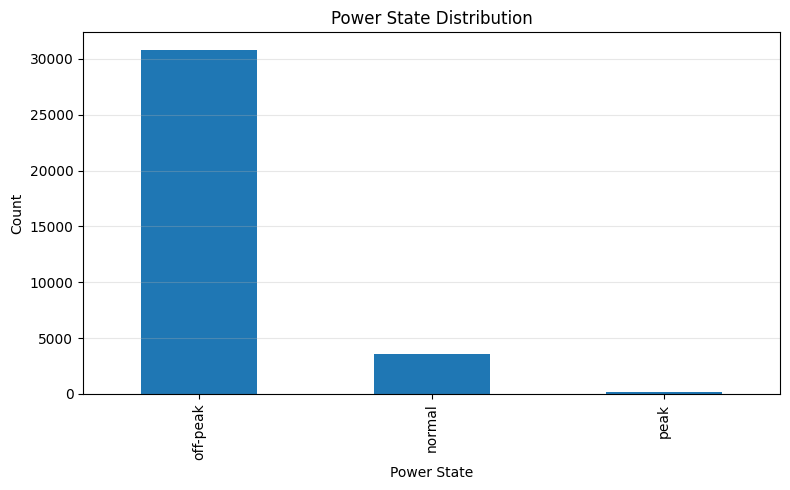

In [11]:
# Check power state distribution (for association mining)
if 'power_state' in df_features.columns:
    print("\nPower State Distribution:")
    print(df_features['power_state'].value_counts())
    
    # Plot distribution
    fig, ax = plt.subplots(figsize=(8, 5))
    df_features['power_state'].value_counts().plot(kind='bar', ax=ax)
    ax.set_xlabel('Power State')
    ax.set_ylabel('Count')
    ax.set_title('Power State Distribution')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('../outputs/figures/02_power_states.png', dpi=100, bbox_inches='tight')
    plt.show()

## 5. Create Profile Features for Clustering

In [12]:
# Create daily profiles for clustering
df_profiles = builder.create_profile_features(
    df_features,
    group_by='date',
    target_col='Global_active_power'
)

print(f"\nProfile features shape: {df_profiles.shape}")
print(f"\nProfile features:")
print(df_profiles.head())

Creating profile features grouped by date...
Created profile with 1442 groups and 8 features

Profile features shape: (1442, 8)

Profile features:
            mean_power  std_power  min_power  max_power  \
group                                                     
2006-12-16    3.120298   0.769168   2.061600   4.222889   
2006-12-17    2.354486   0.862821   0.437733   3.697100   
2006-12-18    1.530435   0.817779   0.276367   3.050567   
2006-12-19    1.157079   0.993433   0.300467   3.879033   
2006-12-20    1.545658   1.204481   0.258667   3.646067   

            night_consumption_ratio  peak_hour_ratio  weekend_ratio  peak_hour  
group                                                                           
2006-12-16                 0.285714         0.571429            1.0         17  
2006-12-17                 0.375000         0.166667            1.0         18  
2006-12-18                 0.375000         0.166667            0.0         20  
2006-12-19                 0.37500

## 6. Save Processed Data

In [13]:
# Save cleaned data
loader.save_processed_data(df_clean, 'cleaned_data.parquet')

# Save feature-engineered data
loader.save_processed_data(df_features, 'features_data.parquet')

# Save profile data
loader.save_processed_data(df_profiles, 'profile_data.parquet')

print("\nAll processed data saved successfully!")

Saved processed data to data\processed\cleaned_data.parquet
Saved processed data to data\processed\features_data.parquet
Saved processed data to data\processed\profile_data.parquet

All processed data saved successfully!


## 7. Summary

In [14]:
print("=" * 80)
print("PREPROCESSING & FEATURE ENGINEERING SUMMARY")
print("=" * 80)

print("\n1. DATA CLEANING:")
print(f"   - Original records: {len(df_raw):,}")
print(f"   - After resampling: {len(df_clean):,}")
print(f"   - Frequency: Hourly")
print(f"   - Missing values handled: Yes")
print(f"   - Outliers detected: {df_clean.get('is_outlier', pd.Series([0])).sum()}")

print("\n2. FEATURES CREATED:")
print(f"   - Total features: {len(df_features.columns)}")
print(f"   - Time features: hour, day_of_week, month, season, etc.")
print(f"   - Lag features: Yes (for forecasting)")
print(f"   - Rolling features: Yes (for forecasting)")
print(f"   - Power states: Yes (for association mining)")

print("\n3. PROFILE DATA:")
print(f"   - Daily profiles: {len(df_profiles)}")
print(f"   - Profile features: {len(df_profiles.columns)}")

print("\n4. READY FOR:")
print("   ✓ Association Pattern Mining")
print("   ✓ Clustering Analysis")
print("   ✓ Anomaly Detection")
print("   ✓ Time Series Forecasting")

print("\n" + "=" * 80)

PREPROCESSING & FEATURE ENGINEERING SUMMARY

1. DATA CLEANING:
   - Original records: 2,075,259
   - After resampling: 34,589
   - Frequency: Hourly
   - Missing values handled: Yes
   - Outliers detected: 6665

2. FEATURES CREATED:
   - Total features: 30
   - Time features: hour, day_of_week, month, season, etc.
   - Lag features: Yes (for forecasting)
   - Rolling features: Yes (for forecasting)
   - Power states: Yes (for association mining)

3. PROFILE DATA:
   - Daily profiles: 1442
   - Profile features: 8

4. READY FOR:
   ✓ Association Pattern Mining
   ✓ Clustering Analysis
   ✓ Anomaly Detection
   ✓ Time Series Forecasting

